In [20]:
import math 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date

In [41]:
data = pd.read_csv(r"C:\Users\Trish\Documents\CMU\INFO VIZ\CMU-MS-DAS-Vis-S26\data\covid19cases_test.csv")
data.isna().sum()
data.dropna(subset=['date'], inplace=True)
data['date'].min()

'2020-02-01'

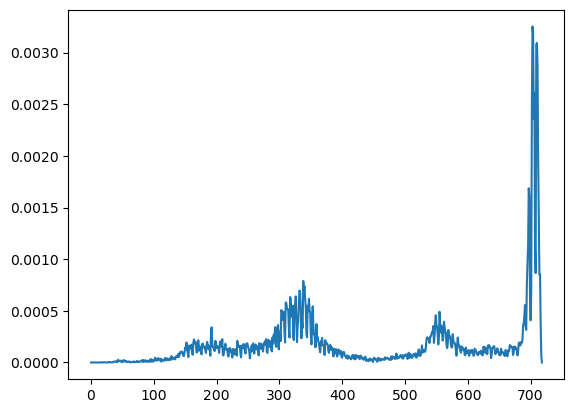

In [43]:
data['date'] = pd.to_datetime(data['date'])
data['days_offset'] = (data['date'] - pd.to_datetime('2020-02-01')).dt.days

# Step 2: Normalize case count by population
data['normalized_cases'] = data['cases'] / data['population']

# Step 3: Plot one county
one_county_df = data[data['area'] == 'Sonoma']
fig, axes = plt.subplots()
axes.plot(one_county_df['days_offset'], one_county_df['normalized_cases'])
plt.show()

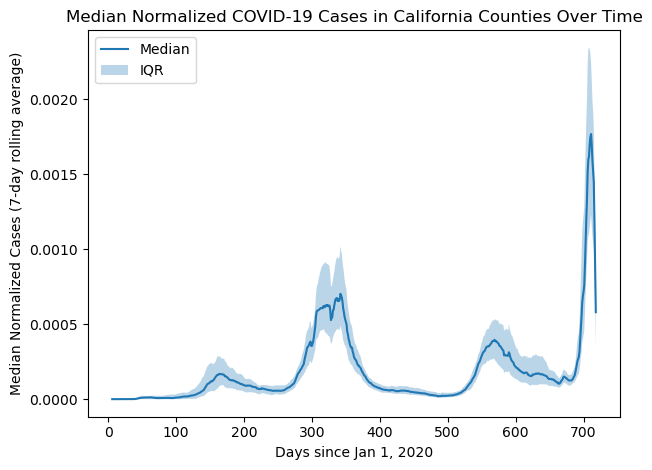

In [49]:
safe_cols_df = data.drop(columns=['date', 'area', 'area_type'])

medians_df = safe_cols_df.groupby('days_offset').median().reset_index()
q1_df = safe_cols_df.groupby('days_offset').quantile(0.25).reset_index()
q3_df = safe_cols_df.groupby('days_offset').quantile(0.75).reset_index()

# Step 5: Sort BEFORE rolling
medians_df = medians_df.sort_values('days_offset')
q1_df = q1_df.sort_values('days_offset')
q3_df = q3_df.sort_values('days_offset')

#  Step 6 rolling averages
medians_df['normalized_cases'] = (medians_df['normalized_cases'].rolling(window=7).mean())

q1_df['normalized_cases'] = (q1_df['normalized_cases'].rolling(window=7).mean())
q3_df['normalized_cases'] = (q3_df['normalized_cases'].rolling(window=7), mean())

# Step 7: Final plot
fig, axes = plt.subplots()

axes.plot(medians_df['days_offset'],medians_df['normalized_cases'],label='Median')
axes.fill_between(q1_df['days_offset'],q1_df['normalized_cases'],q3_df['normalized_cases'],alpha=0.3,label='IQR')
axes.set_xlabel('Days since Jan 1, 2020')
axes.set_ylabel('Median Normalized Cases (7-day rolling average)')
axes.set_title('Median Normalized COVID-19 Cases in California Counties Over Time')
axes.legend()

plt.tight_layout()
plt.savefig('california_covid19_median_normalized_cases.png')
plt.show()
